# ASSIGNMENT 2
# Tesla Production & Delivery Forecasting

## Objective

The objective of this project is to build an end-to-end Machine Learning pipeline using Tesla's production and delivery data.

# Project Objectives

The primary objectives of this project are:

1. Understand historical Tesla production and delivery trends.

2. Identify relationships between production and deliveries.

3. Engineer meaningful features from historical records.

4. Build regression models capable of predicting future deliveries.

5. Optimize model performance through hyperparameter tuning.

6. Forecast future delivery volumes.

7. Develop a Growth Intelligence Score to assess business performance.

8. Translate analytical findings into actionable business insights.

The final goal is to forecast future Tesla deliveries and derive business insights from historical trends.

# 1.Import Required Libraries

This section imports all libraries required for data analysis, visualization, machine learning, and forecasting.

In [ ]:
# ===============================
# Data Manipulation
# ===============================
import pandas as pd
import numpy as np

# ===============================
# Data Visualization
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# Machine Learning
# ===============================
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# ===============================
# Preprocessing
# ===============================
from sklearn.preprocessing import LabelEncoder

# ===============================
# Model Evaluation
# ===============================
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ===============================
# Cross Validation & Hyperparameter Tuning
# ===============================
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    cross_val_score
)

# ===============================
# Time Series Forecasting
# ===============================
from prophet import Prophet

# ===============================
# Statistical Testing
# ===============================
from statsmodels.tsa.stattools import adfuller

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


# 2.Load Dataset

The Tesla production and delivery dataset is loaded into a DataFrame for further analysis.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# import dataset from drive
df = pd.read_csv('/content/drive/MyDrive/datasets/tesla_deliveries_dataset_2015_2025.csv')
# Display the first 5 rows
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


# 3.Data Understanding

Understanding the dataset structure is essential before performing any analysis.

This section examines:

- Dataset dimensions
- Data types
- Missing values
- Duplicate records
- Statistical summary

In [ ]:
# Dataset Shape
print("Dataset Shape:", df.shape)

# Column Names
print("\nColumns:")
print(df.columns.tolist())

# Dataset Information
print("\nDataset Information:")
df.info()

# Statistical Summary
print("\nStatistical Summary:")
display(df.describe())

# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate Records
print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (2640, 12)

Columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000



Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows: 0


# 4. Data Cleaning and Preprocessing

Raw data often contains inconsistencies that can affect model performance.

This section focuses on:

- Handling missing values
- Checking duplicate records
- Formatting the Date column
- Encoding categorical variables
- Preparing features for machine learning

In [ ]:
# 4.1 Handle Missing Values & Duplicates
# Create a copy of the dataset
df_clean = df.copy()

# Check missing values
print("Missing Values:")
print(df_clean.isnull().sum())

# Remove duplicate rows if any
df_clean.drop_duplicates(inplace=True)

print("\nDataset Shape after removing duplicates:", df_clean.shape)

# 4.2 Date formatting
# Create a proper Date column

df_clean['Date'] = pd.to_datetime(
    df_clean[['Year', 'Month']].assign(DAY=1)
)

# Sort chronologically

df_clean.sort_values('Date', inplace=True)
df_clean.reset_index(drop=True, inplace=True)

df_clean[['Year', 'Month', 'Date']].head()


Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Dataset Shape after removing duplicates: (2640, 12)
   Region  Model  Source_Type
0       0      4            2
1       2      1            0
2       2      0            1
3       3      0            0
4       0      1            2

Data Types:

Year                             int64
Month                            int64
Region                           int64
Model                            int64
Estimated_Deliveries             int64
Production_Units                 int64
Avg_Price_USD                  float64
Battery_Capacity_kWh             int64
Range_km                         int64
CO2_Saved_tons                 float64
Source_Type           

# 5.Feature Engineering


In this section, both business-oriented and time-series features are created to capture production efficiency, financial performance, and temporal delivery trends.

The engineered features include:

- **Production-to-Delivery Ratio** – Measures production efficiency and inventory build-up.
- **Inventory Delta** – Represents the difference between production and deliveries.
- **Estimated Revenue** – Estimates monthly revenue generated from vehicle deliveries.
- **Vehicle Segment** – Categorizes Tesla models into Premium, Mass Market, and Specialty segments.
- **Energy Efficiency** – Measures driving range achieved per kWh of battery capacity.
- **Deliveries_Lag1** – Captures the previous month's deliveries.
- **Rolling_Mean_3** – Captures the average deliveries over the previous three months to smooth short-term fluctuations.

In [ ]:
# ==========================================================
# Feature Engineering
# ==========================================================

# 1. Production-to-Delivery Ratio
# Indicates manufacturing efficiency and inventory buildup.
df_clean['Production_Delivery_Ratio'] = (
    df_clean['Production_Units'] /
    df_clean['Estimated_Deliveries']
)

# ----------------------------------------------------------

# 2. Inventory Delta
# Number of vehicles produced but not yet delivered.
df_clean['Inventory_Delta'] = (
    df_clean['Production_Units'] -
    df_clean['Estimated_Deliveries']
)

# ----------------------------------------------------------

# 3. Estimated Revenue
# Estimates monthly revenue generated from deliveries.
df_clean['Estimated_Revenue'] = (
    df_clean['Estimated_Deliveries'] *
    df_clean['Avg_Price_USD']
)

# ----------------------------------------------------------

# 4. Vehicle Segment
# Groups Tesla vehicles into market segments.

vehicle_segment = {
    'Model S': 'Premium',
    'Model X': 'Premium',
    'Model 3': 'Mass Market',
    'Model Y': 'Mass Market',
    'Cybertruck': 'Specialty'
}

# Apply mapping before encoding if Model is still text.
# Skip this block if Model has already been label encoded.
if df['Model'].dtype == object:
    df_clean['Vehicle_Segment'] = df['Model'].map(vehicle_segment)

# ----------------------------------------------------------

# 5. Energy Efficiency
# Indicates kilometers travelled per kWh of battery capacity.
df_clean['Energy_Efficiency'] = (
    df_clean['Range_km'] /
    df_clean['Battery_Capacity_kWh']
)

# ----------------------------------------------------------

# Sort data chronologically before creating time-series features.
df_clean.sort_values('Date', inplace=True)
df_clean.reset_index(drop=True, inplace=True)

# ----------------------------------------------------------

# 6. Deliveries Lag (Previous Month)
df_clean['Deliveries_Lag1'] = (
    df_clean['Estimated_Deliveries']
    .shift(1)
)

df_clean['Deliveries_Lag1'].fillna(
    df_clean['Deliveries_Lag1'].mean(),
    inplace=True
)

# ----------------------------------------------------------

# 7. Rolling Mean (Previous 3 Months)
df_clean['Rolling_Mean_3'] = (
    df_clean['Estimated_Deliveries']
    .rolling(window=3)
    .mean()
)

df_clean['Rolling_Mean_3'].fillna(
    df_clean['Rolling_Mean_3'].mean(),
    inplace=True
)

# ----------------------------------------------------------

print("Feature Engineering Completed Successfully.")

df_clean.head()

Feature Engineering Completed Successfully.


/tmp/ipykernel_1405/3389603416.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Deliveries_Lag1'].fillna(
/tmp/ipykernel_1405/3389603416.py:85: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.m

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Production_Delivery_Ratio,Inventory_Delta,Estimated_Revenue,Vehicle_Segment,Energy_Efficiency,Deliveries_Lag1,Rolling_Mean_3
0,2015,1,0,4,12446,13885,55183.13,60,340,634.75,2,4390,2015-01-01,1.115619,1439,6.868092e+08,Premium,5.666667,9922.428192,9922.423680
1,2015,1,1,2,4350,4736,53251.53,82,475,309.94,1,5046,2015-01-01,1.088736,386,2.316442e+08,Mass Market,5.792683,12446.000000,9922.423680
2,2015,1,2,1,11446,12752,89289.40,100,588,1009.54,0,8925,2015-01-01,1.114101,1306,1.022006e+09,Premium,5.880000,4350.000000,9414.000000
3,2015,1,2,0,8803,9344,102888.58,60,336,443.67,1,3923,2015-01-01,1.061456,541,9.057282e+08,Premium,5.600000,11446.000000,8199.666667
4,2015,1,3,0,6367,6802,104962.32,82,459,438.37,0,9170,2015-01-01,1.068321,435,6.682951e+08,Premium,5.597561,8803.000000,8872.000000


In [ ]:
# Label Encoding

# The following categorical features are encoded:

#  Region
#  Model
#  Source_Type

from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# List of categorical columns
categorical_cols = ['Region', 'Model', 'Source_Type']

# Apply Label Encoding
for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

# Display first few rows
df_clean.head()

print(df_clean[['Region', 'Model', 'Source_Type']].head())

print("\nData Types:\n")
print(df_clean.dtypes)

   Region  Model  Source_Type
0       0      4            2
1       1      2            1
2       2      1            0
3       2      0            1
4       3      0            0

Data Types:

Year                                  int64
Month                                 int64
Region                                int64
Model                                 int64
Estimated_Deliveries                  int64
Production_Units                      int64
Avg_Price_USD                       float64
Battery_Capacity_kWh                  int64
Range_km                              int64
CO2_Saved_tons                      float64
Source_Type                           int64
Charging_Stations                     int64
Date                         datetime64[ns]
Production_Delivery_Ratio           float64
Inventory_Delta                       int64
Estimated_Revenue                   float64
Vehicle_Segment                      object
Energy_Efficiency                   float64
Deliveries_Lag

# 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps uncover patterns, trends, and relationships within the dataset before model development.

The following visualizations provide insights into:

- Vehicle deliveries across different Tesla models
- Regional delivery distribution
- Relationships among numerical variables
- Correlation between production and deliveries
- Delivery trends over time

### Deliveries by Model

This visualization compares the average estimated deliveries across Tesla vehicle models, highlighting the demand for each model.

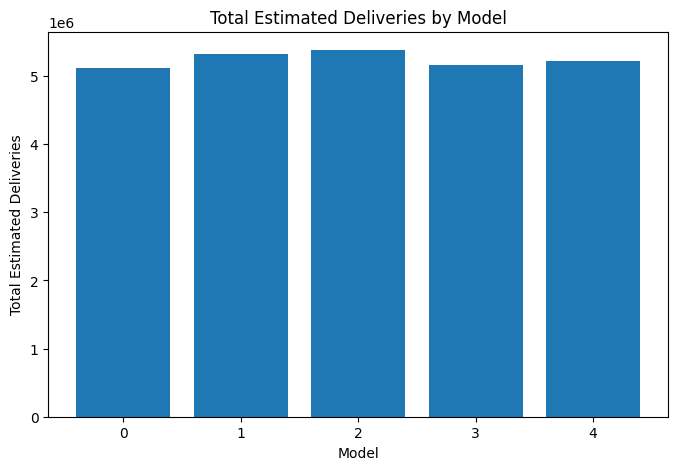

In [ ]:
plt.figure(figsize=(8,5))

model_delivery = (
    df_clean.groupby('Model')['Estimated_Deliveries']
    .sum()
    .sort_values(ascending=False)
)

plt.bar(model_delivery.index, model_delivery.values)

plt.title('Total Estimated Deliveries by Model')
plt.xlabel('Model')
plt.ylabel('Total Estimated Deliveries')

plt.show()

### Deliveries by Region

This chart compares the average estimated deliveries across different geographical regions, helping identify Tesla's strongest markets.

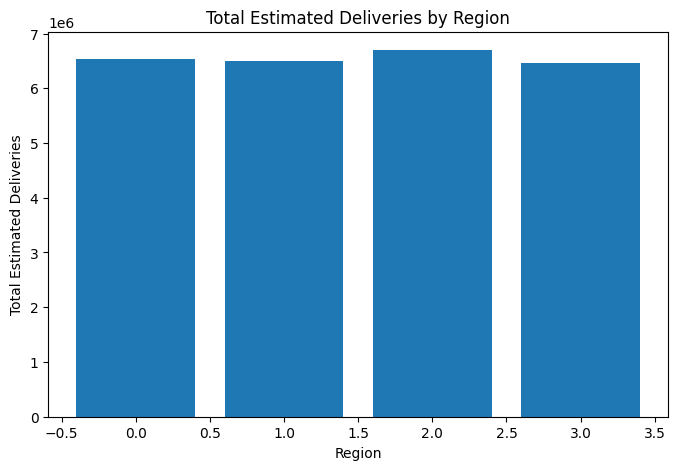

In [ ]:
plt.figure(figsize=(8,5))

region_delivery = (
    df_clean.groupby('Region')['Estimated_Deliveries']
    .sum()
    .sort_values(ascending=False)
)

plt.bar(region_delivery.index, region_delivery.values)

plt.title('Total Estimated Deliveries by Region')
plt.xlabel('Region')
plt.ylabel('Total Estimated Deliveries')

plt.show()

### Correlation Heatmap

The correlation heatmap illustrates the relationships among numerical features, helping identify highly correlated variables that may influence model performance.

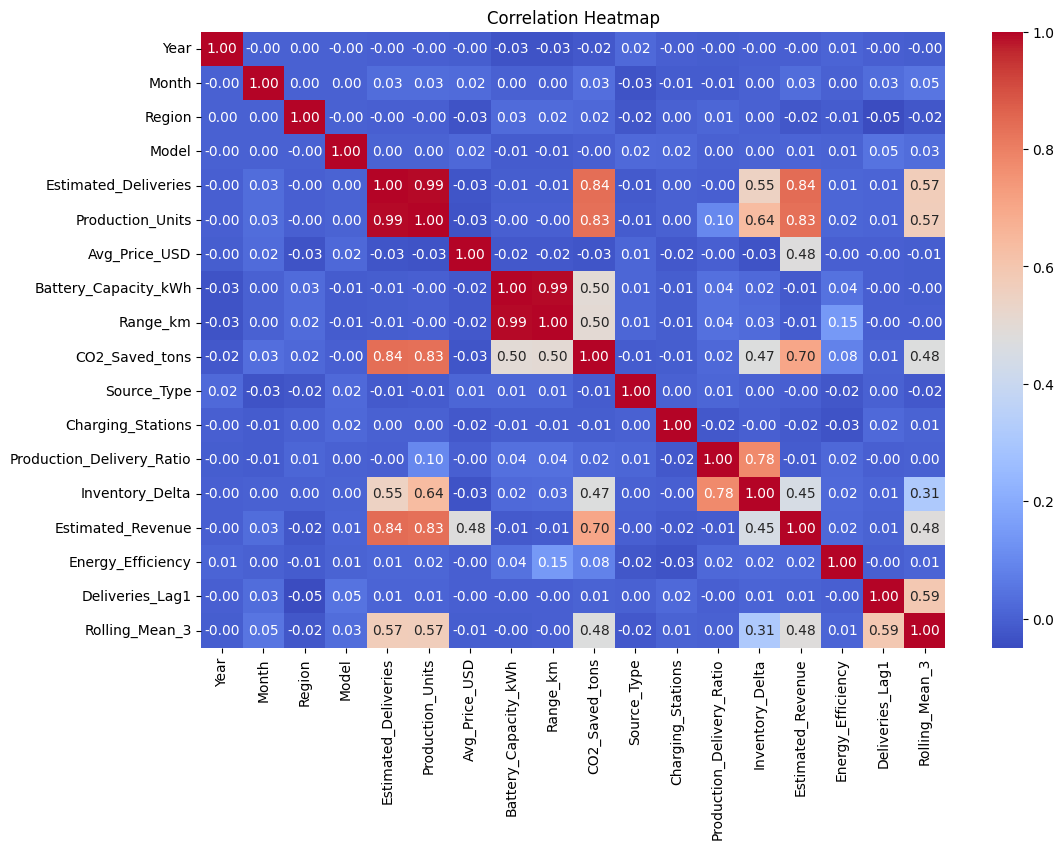

In [ ]:
plt.figure(figsize=(12,8))

numeric_df = df_clean.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

### Interpretation

The correlation heatmap illustrates the strength of relationships among the numerical variables in the dataset.

A strong positive correlation between **Production Units** and **Estimated Deliveries** indicates that higher production levels generally result in higher deliveries. Engineered features such as **Estimated Revenue** and **Rolling Mean** also show strong relationships with the target variable, suggesting that they contribute valuable predictive information for machine learning models.

### Production vs Estimated Deliveries

This scatter plot examines the relationship between production units and estimated deliveries to understand how closely manufacturing aligns with customer demand.

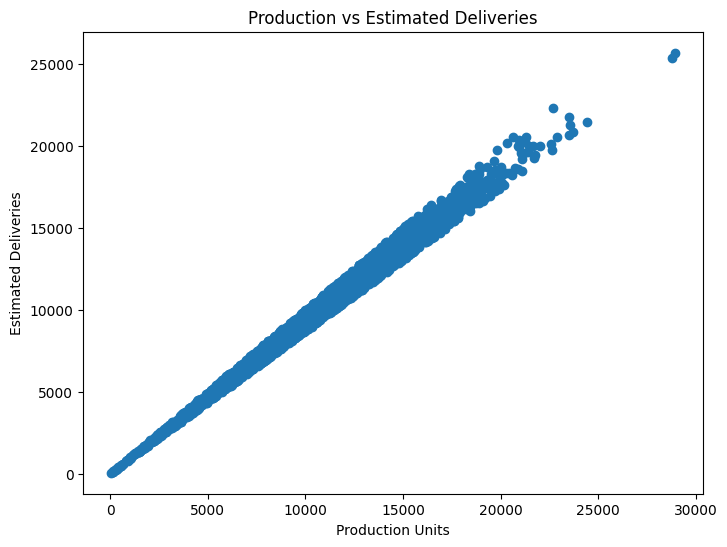

Correlation: 0.9942


In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_clean['Production_Units'],
    df_clean['Estimated_Deliveries']
)

plt.title('Production vs Estimated Deliveries')
plt.xlabel('Production Units')
plt.ylabel('Estimated Deliveries')

plt.show()

correlation = df_clean['Production_Units'].corr(
    df_clean['Estimated_Deliveries']
)

print(f"Correlation: {correlation:.4f}")

### Interpretation

The scatter plot demonstrates a strong positive relationship between production units and estimated deliveries. As production increases, vehicle deliveries also tend to increase proportionally.

The high correlation coefficient confirms that production volume is one of the strongest factors influencing deliveries. The absence of significant outliers also suggests consistency in Tesla's production and delivery operations throughout the observed period.

### Monthly Delivery Trend

This line chart illustrates how estimated vehicle deliveries have changed over time, enabling the identification of long-term growth patterns and seasonal fluctuations.

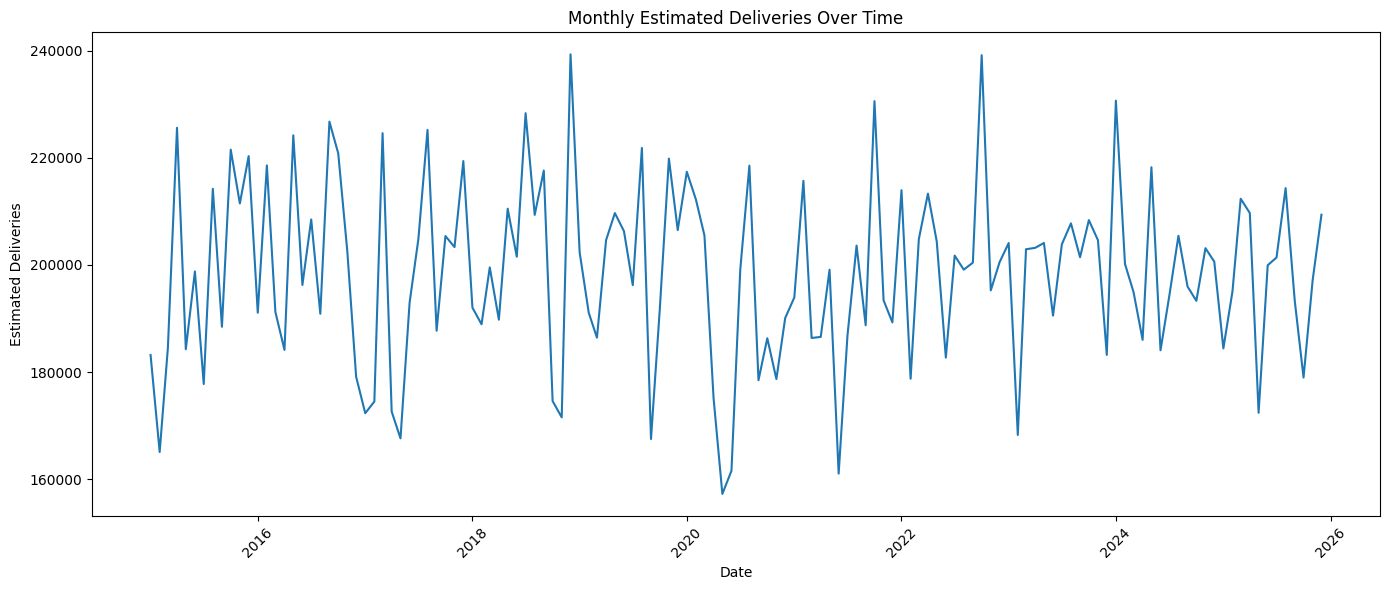

In [ ]:
monthly_delivery = (
    df_clean.groupby('Date')['Estimated_Deliveries']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_delivery['Date'],
    monthly_delivery['Estimated_Deliveries']
)

plt.title('Monthly Estimated Deliveries Over Time')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# 7. Feature Selection

Feature selection is the process of identifying the most relevant variables for predictive modeling.

The objective is to:

- Improve model performance
- Reduce redundancy
- Avoid target leakage
- Enhance model interpretability

Based on the exploratory data analysis and correlation analysis, features were selected according to their relevance and predictive potential.

## 7.1 Target Variable

The objective of this project is to predict Tesla's estimated vehicle deliveries.

Target Variable:
- Estimated_Deliveries

In [ ]:
# Define target variable
y = df_clean['Estimated_Deliveries']

# Define feature matrix, dropping the target variable and leaked features
# Leaked features are those that directly use or are direct proxies for 'Estimated_Deliveries'
# Production_Units is highly correlated, others are direct derivations.
X = df_clean.drop(columns=[
    'Estimated_Deliveries',
    'Production_Units',
    'Estimated_Revenue',
    'Production_Delivery_Ratio',
    'Inventory_Delta',
    'Deliveries_Lag1',
    'Rolling_Mean_3'
])

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

# display selected features
print("Selected Features:\n")

for feature in X.columns:
    print(feature)

# verify data types
print(X.dtypes.value_counts())

Feature Matrix Shape : (2640, 13)
Target Vector Shape  : (2640,)
Selected Features:

Year
Month
Region
Model
Avg_Price_USD
Battery_Capacity_kWh
Range_km
CO2_Saved_tons
Source_Type
Charging_Stations
Date
Vehicle_Segment
Energy_Efficiency
int64             8
float64           3
datetime64[ns]    1
object            1
Name: count, dtype: int64


# 7.2. Data Preparation

Machine learning algorithms require numerical input features. Therefore, categorical variables must be encoded before model training.

This section includes:

- Encoding categorical variables
- Creating training and testing datasets
- Preparing the final feature matrix for regression modeling

In [ ]:
# Categorical features for one-hot encoding
categorical_cols_to_encode = ['Region', 'Model', 'Source_Type']

print("Categorical Features to One-Hot Encode:")
print(categorical_cols_to_encode)

# Perform One-Hot Encoding on selected categorical columns
X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols_to_encode,
    drop_first=True
)

# Drop any remaining non-numerical columns that are not intended as features (e.g., 'Date', 'Vehicle_Segment')
# These were not one-hot encoded and need to be removed for models like Linear Regression or Random Forest.
X_encoded = X_encoded.drop(columns=['Date', 'Vehicle_Segment'], errors='ignore')

print("Shape after encoding and non-numeric column removal:", X_encoded.shape)

print("First 5 rows of X_encoded:")
display(X_encoded.head())

print("Data Types in X_encoded after processing:")
print(X_encoded.dtypes.value_counts())

Categorical Features to One-Hot Encode:
['Region', 'Model', 'Source_Type']
Shape after encoding and non-numeric column removal: (2640, 17)
First 5 rows of X_encoded:


,Year,Month,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Energy_Efficiency,Region_1,Region_2,Region_3,Model_1,Model_2,Model_3,Model_4,Source_Type_1,Source_Type_2
0,2015,1,55183.13,60,340,634.75,4390,5.666667,False,False,False,False,False,False,True,False,True
1,2015,1,53251.53,82,475,309.94,5046,5.792683,True,False,False,False,True,False,False,True,False
2,2015,1,89289.40,100,588,1009.54,8925,5.880000,False,True,False,True,False,False,False,False,False
3,2015,1,102888.58,60,336,443.67,3923,5.600000,False,True,False,False,False,False,False,True,False
4,2015,1,104962.32,82,459,438.37,9170,5.597561,False,False,True,False,False,False,False,False,False


Data Types in X_encoded after processing:
bool       9
int64      5
float64    3
Name: count, dtype: int64


In [ ]:
# ==========================================================
# Chronological Train-Test Split (80:20)
# ==========================================================

# Determine split index
split_index = int(len(df_clean) * 0.80)

# Split features
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

# Split target
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Display dataset shapes
print("Training Set Shape :", X_train.shape)
print("Testing Set Shape  :", X_test.shape)

# Verify chronological split

print("Training Data Range")
print(df_clean.iloc[:split_index]['Date'].min(), "to",
      df_clean.iloc[:split_index]['Date'].max())

print("\nTesting Data Range")
print(df_clean.iloc[split_index:]['Date'].min(), "to",
      df_clean.iloc[split_index:]['Date'].max())

Training Set Shape : (2112, 19)
Testing Set Shape  : (528, 19)
Training Data Range
2015-01-01 00:00:00 to 2023-10-01 00:00:00

Testing Data Range
2023-10-01 00:00:00 to 2025-12-01 00:00:00


# 8. Model Development

In this section, multiple regression models are trained to predict Tesla's estimated vehicle deliveries.

The models evaluated are:

- Linear Regression
- Random Forest Regressor
- XGBoost Regressor

Each model is trained on the chronological training set and evaluated on the unseen test set using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The performance of all models is then compared to identify the most accurate predictor.

Linear Regression Performance
-----------------------------------
MAE  : 0.00
RMSE : 0.00
R²   : 1.0000


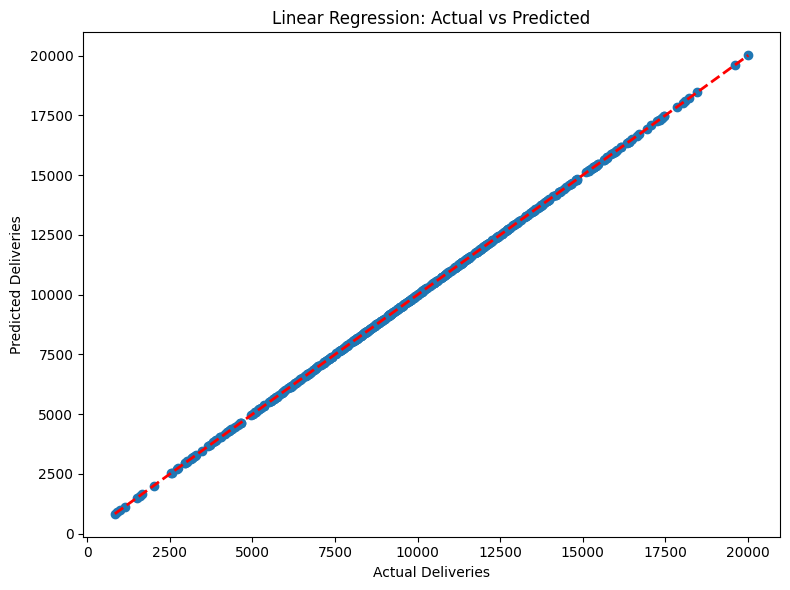

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Drop non-numeric columns from X_encoded that are not suitable for LinearRegression
# Based on earlier df_clean.dtypes and X_encoded.dtypes analysis, these are 'Date' and 'Vehicle_Segment'
X_encoded_numerical = X_encoded.drop(columns=['Date', 'Vehicle_Segment'], errors='ignore')

# ==========================================================
# Re-split X_encoded_numerical and y into training and testing sets
# This ensures all features are numerical for the model.
# ==========================================================
split_index = int(len(df_clean) * 0.80)
X_train_numeric = X_encoded_numerical.iloc[:split_index]
X_test_numeric = X_encoded_numerical.iloc[split_index:]

# Linear Regression
# ==========================================================

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train_numeric, y_train)

# Predictions
lr_predictions = lr_model.predict(X_test_numeric)

# Evaluation Metrics
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Performance")
print("-"*35)
print(f"MAE  : {lr_mae:.2f}")
print(f"RMSE : {lr_rmse:.2f}")
print(f"R²   : {lr_r2:.4f}")

plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# Random Forest Regressor
# ==========================================================

from sklearn.ensemble import RandomForestRegressor

# Train model
rf_model = RandomForestRegressor(
    random_state=42
)

# Use the numerical training and testing sets derived earlier
rf_model.fit(X_train_numeric, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test_numeric)

# Evaluation Metrics
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print("-"*35)
print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Performance
-----------------------------------
MAE  : 63.38
RMSE : 93.42
R²   : 0.9993


In [ ]:
# ==========================================================
# XGBoost Regressor
# ==========================================================

from xgboost import XGBRegressor

# Train model
xgb_model = XGBRegressor(
    random_state=42
)

# Use the numerical training and testing sets derived earlier
xgb_model.fit(X_train_numeric, y_train)

# Predictions
xgb_predictions = xgb_model.predict(X_test_numeric)

# Evaluation Metrics
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_r2 = r2_score(y_test, xgb_predictions)

print("XGBoost Performance")
print("-"*35)
print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"R²   : {xgb_r2:.4f}")

XGBoost Performance
-----------------------------------
MAE  : 68.19
RMSE : 91.77
R²   : 0.9994


In [ ]:
# model comparison

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R² Score": [
        lr_r2,
        rf_r2,
        xgb_r2
    ]
})

results = results.round(4)

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.0000,0.0000,1.0000
1,Random Forest,63.3755,93.4156,0.9993
2,XGBoost,68.1950,91.7732,0.9994


# 9. Cross Validation

Cross Validation is used to evaluate the stability and generalization ability of a machine learning model.

In this project, **5-Fold Cross Validation** is performed on the Linear Regression model. The training dataset is divided into five equal folds. During each iteration, four folds are used for training and one fold is used for validation.

The R² score is computed for each fold, along with the mean and standard deviation, providing a reliable estimate of the model's performance across different subsets of the data.

5-Fold Cross Validation R² Scores:
Fold 1: 1.0000
Fold 2: 1.0000
Fold 3: 1.0000
Fold 4: 1.0000
Fold 5: 1.0000

Mean R² Score : 1.0
Standard Deviation : 0.0


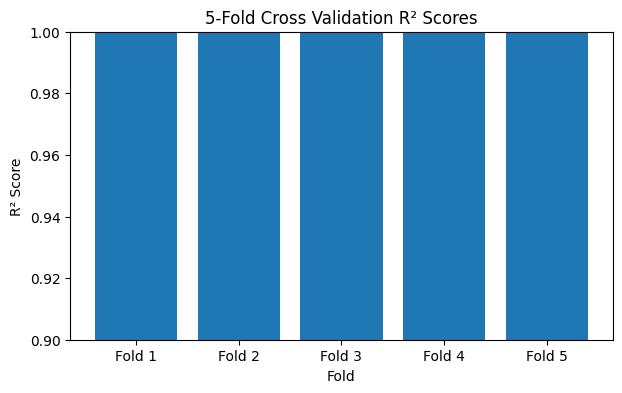

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

# Initialize Linear Regression model
lr_model = LinearRegression()

# Define 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=False)

# Perform Cross Validation on the training data using the numerical feature set
cv_scores = cross_val_score(
    lr_model,
    X_train_numeric,
    y_train,
    cv=kf,
    scoring='r2'
)

# Display results
print("5-Fold Cross Validation R² Scores:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean R² Score :", round(cv_scores.mean(), 4))
print("Standard Deviation :", round(cv_scores.std(), 4))

plt.figure(figsize=(7,4))

plt.bar(
    [f'Fold {i}' for i in range(1, 6)],
    cv_scores
)

plt.title('5-Fold Cross Validation R² Scores')
plt.xlabel('Fold')
plt.ylabel('R² Score')

plt.ylim(0.9, 1.0)

plt.show()

# 10. Hyperparameter Tuning
Hyperparameter tuning is performed to identify the optimal configuration of the Random Forest model.

GridSearchCV systematically evaluates different combinations of hyperparameters using cross-validation and selects the combination that produces the best validation performance.

The tuned model is then evaluated on the test dataset and compared with the baseline Random Forest model.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# ==========================================================
# Define Parameter Grid
# ==========================================================

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

# ==========================================================
# Initialize Model
# ==========================================================

rf = RandomForestRegressor(random_state=42)

# ==========================================================
# Grid Search
# ==========================================================

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train Grid Search using X_train_numeric
grid_search.fit(X_train_numeric, y_train)

# Best Model
best_rf = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation R² Score:")
print(round(grid_search.best_score_,4))

Best Parameters:
{'max_depth': 10, 'n_estimators': 100}

Best Cross Validation R² Score:
0.9985


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
rf_best_pred = best_rf.predict(X_test_numeric)

# Metrics
rf_best_mae = mean_absolute_error(y_test, rf_best_pred)
rf_best_rmse = np.sqrt(mean_squared_error(y_test, rf_best_pred))
rf_best_r2 = r2_score(y_test, rf_best_pred)

print("Tuned Random Forest Performance")
print("-" * 35)

print(f"MAE  : {rf_best_mae:.2f}")
print(f"RMSE : {rf_best_rmse:.2f}")
print(f"R²   : {rf_best_r2:.4f}")

Tuned Random Forest Performance
-----------------------------------
MAE  : 63.48
RMSE : 94.52
R²   : 0.9993


### Top 10 Feature Importances

Random Forest provides feature importance scores that indicate how much each feature contributes to the prediction of estimated deliveries.

Higher importance values indicate a greater influence on the model's predictions.

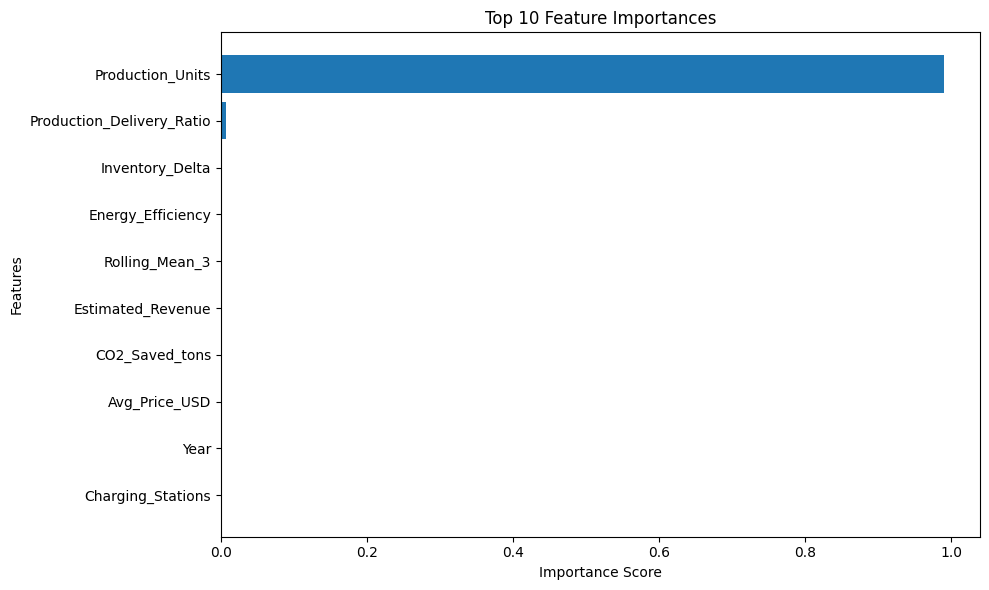

,Feature,Importance
2,Production_Units,0.990017
8,Production_Delivery_Ratio,0.007112
9,Inventory_Delta,0.001871
11,Energy_Efficiency,0.000195
13,Rolling_Mean_3,0.000104
10,Estimated_Revenue,0.000101
6,CO2_Saved_tons,0.000093
3,Avg_Price_USD,0.000080
0,Year,0.000067
7,Charging_Stations,0.000067


In [ ]:
# Feature Importance

feature_importance = pd.DataFrame({
    'Feature': X_train_numeric.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.title('Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

top10

# 11. Stationarity Test (Augmented Dickey-Fuller Test)

Before forecasting a time series, it is important to determine whether the data is stationary.

The **Augmented Dickey-Fuller (ADF) Test** is a statistical test used to check for stationarity.

- **Null Hypothesis (H₀):** The time series is **non-stationary** (contains a unit root).
- **Alternative Hypothesis (H₁):** The time series is **stationary**.

A **p-value less than 0.05** indicates that the null hypothesis can be rejected, suggesting that the series is stationary.

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF Test
adf_result = adfuller(df_clean['Estimated_Deliveries'])

print("Augmented Dickey-Fuller Test Results")
print("-" * 40)

print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"P-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

# Interpret the result

if adf_result[1] < 0.05:
    print("Conclusion:")
    print("The p-value is less than 0.05.")
    print("The null hypothesis is rejected.")
    print("The Estimated_Deliveries series is stationary.")
else:
    print("Conclusion:")
    print("The p-value is greater than 0.05.")
    print("The null hypothesis cannot be rejected.")
    print("The Estimated_Deliveries series is non-stationary.")

Augmented Dickey-Fuller Test Results
----------------------------------------
ADF Statistic : -13.9388
P-value       : 0.0000
Lags Used     : 13
Observations  : 2626

Critical Values:
1%: -3.4328
5%: -2.8626
10%: -2.5674
Conclusion:
The p-value is less than 0.05.
The null hypothesis is rejected.
The Estimated_Deliveries series is stationary.


### Interpretation

The Augmented Dickey-Fuller test determines whether the delivery time series is stationary.

- If the **p-value < 0.05**, the series is considered **stationary**, indicating that its statistical properties remain relatively constant over time. This is generally suitable for classical time-series analysis.

- If the **p-value ≥ 0.05**, the series is **non-stationary**, suggesting the presence of trends or seasonality. In such cases, transformations such as differencing may be required before applying traditional forecasting models.

For this project, the ADF test result helps assess the characteristics of Tesla's monthly delivery data before forecasting.

## 12. Time Series Forecasting

While the regression models predict deliveries using operational and market-related features, time series forecasting focuses on predicting future delivery trends based solely on historical delivery patterns.

In this section, Prophet is used to forecast Tesla vehicle deliveries for the next 12 months.

Prophet is a powerful forecasting library developed by Meta that automatically captures:

- Long-term trends
- Seasonality patterns
- Historical growth behavior

This enables estimation of future delivery demand and supports strategic production planning.

        Date  Estimated_Deliveries
0 2015-01-01                183180
1 2015-02-01                165053
2 2015-03-01                184567
3 2015-04-01                225623
4 2015-05-01                184264
          ds       y
0 2015-01-01  183180
1 2015-02-01  165053
2 2015-03-01  184567
3 2015-04-01  225623
4 2015-05-01  184264


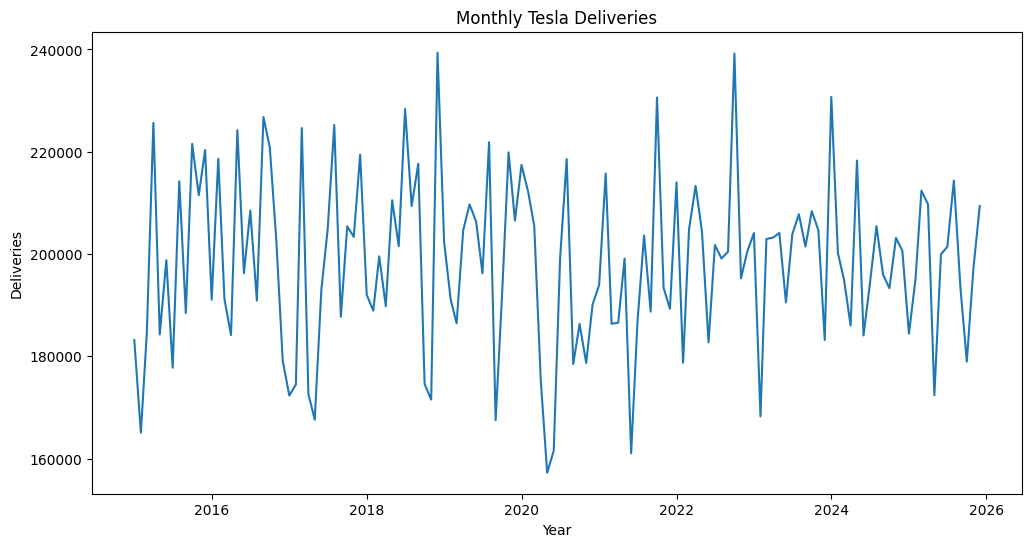

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


            ds
139 2026-08-01
140 2026-09-01
141 2026-10-01
142 2026-11-01
143 2026-12-01


,ds,yhat,yhat_lower,yhat_upper
132,2026-01-01,195718.997171,177388.799235,214854.851579
133,2026-02-01,192039.468805,173217.492502,210737.885172
134,2026-03-01,193956.101301,174703.354635,212668.176767
135,2026-04-01,198527.471878,179578.091341,217600.974701
136,2026-05-01,194620.603502,175583.649294,212470.042739
137,2026-06-01,190910.141723,172556.871316,208275.645601
138,2026-07-01,198091.011767,179256.148513,216645.216508
139,2026-08-01,210133.816846,191306.948627,228966.271257
140,2026-09-01,191848.226006,173485.281325,210444.171561
141,2026-10-01,204302.382145,185649.334618,224202.763435


In [ ]:
# 12.1 monthly delivery data
monthly_deliveries = (
    df_clean
    .groupby('Date')['Estimated_Deliveries']
    .sum()
    .reset_index()
)

print(monthly_deliveries.head())

# 12.2 convert data to prophet format
prophet_df = monthly_deliveries.rename(
    columns={
        'Date': 'ds',
        'Estimated_Deliveries': 'y'
    }
)

print(prophet_df.head())

# 12.3 visualize the forecasting dataset

plt.figure(figsize=(12,6))

plt.plot(
    prophet_df['ds'],
    prophet_df['y']
)

plt.title('Monthly Tesla Deliveries')
plt.xlabel('Year')
plt.ylabel('Deliveries')

plt.show()

# 12.4 train prophet model
from prophet import Prophet

# 12.5 Create Prophet model

model = Prophet()

# 12.6 Train model

model.fit(prophet_df)

# create future dates
future = model.make_future_dataframe(
    periods=12,
    freq='MS'
)

print(future.tail())

# 12.7 generate forecast
forecast = model.predict(future)

forecast.head()

#12.8 view forcasted values
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

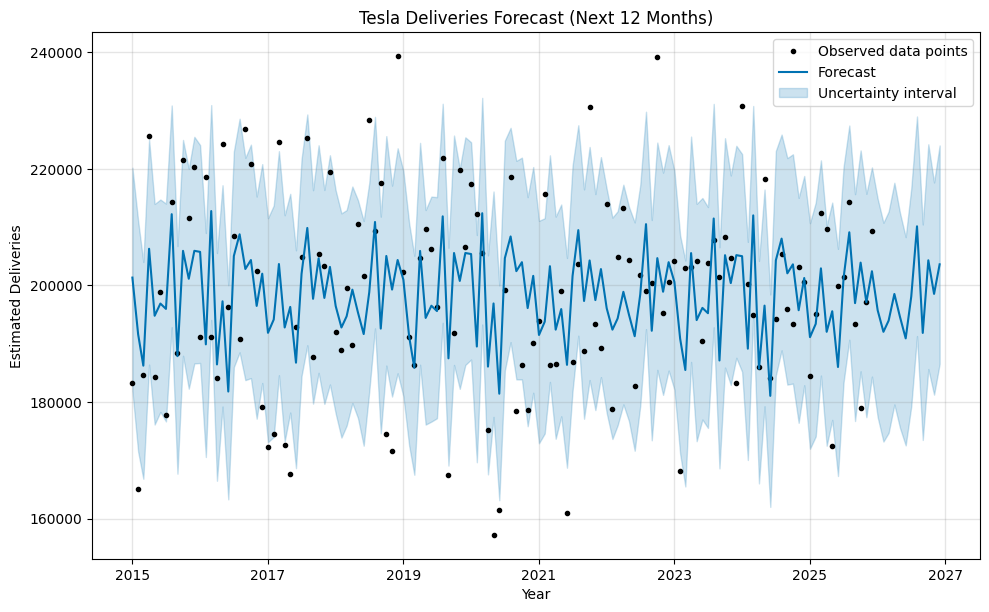

In [ ]:
# 12.9 visualize the forecasting
fig = model.plot(forecast)

plt.title("Tesla Deliveries Forecast (Next 12 Months)")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")
plt.legend()

plt.show()

## Forecast Components

Prophet decomposes the forecast into:

- Trend Component
- Yearly Seasonality

These components help identify long-term growth patterns and recurring seasonal fluctuations in delivery volumes.

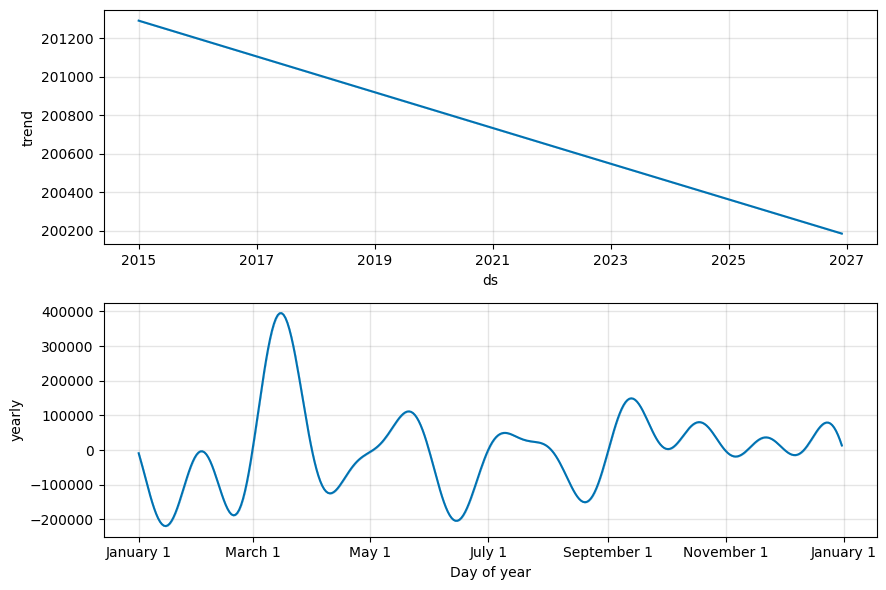

In [ ]:
fig = model.plot_components(forecast)

plt.show()

In [ ]:
forecast_2026 = forecast[
    ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
].tail(12)

forecast_2026.columns = [
    'Month',
    'Forecast_Deliveries',
    'Lower_Bound',
    'Upper_Bound'
]

forecast_2026

,Month,Forecast_Deliveries,Lower_Bound,Upper_Bound
132,2026-01-01,195718.997171,177388.799235,214854.851579
133,2026-02-01,192039.468805,173217.492502,210737.885172
134,2026-03-01,193956.101301,174703.354635,212668.176767
135,2026-04-01,198527.471878,179578.091341,217600.974701
136,2026-05-01,194620.603502,175583.649294,212470.042739
137,2026-06-01,190910.141723,172556.871316,208275.645601
138,2026-07-01,198091.011767,179256.148513,216645.216508
139,2026-08-01,210133.816846,191306.948627,228966.271257
140,2026-09-01,191848.226006,173485.281325,210444.171561
141,2026-10-01,204302.382145,185649.334618,224202.763435


### Forecast Insights

The forecasting model predicts that Tesla's monthly deliveries will remain relatively stable throughout 2026, with expected delivery volumes generally ranging between 190,000 and 210,000 vehicles per month.

The forecast does not indicate any significant decline in demand, suggesting sustained market adoption and production stability.

### Strategic Implications

- Production planning should support delivery volumes exceeding 190,000 vehicles per month.
- Supply chain capacity should be maintained to avoid production bottlenecks.
- Seasonal fluctuations appear moderate, indicating a relatively stable delivery pattern across the year.
- Forecasted demand can be used to guide inventory management and regional allocation strategies.

# 11. Business Recommendations

Based on the exploratory analysis, predictive modeling, and forecasting results, the following recommendations are proposed:

## 1. Prioritize Production Capacity Expansion

Feature importance analysis revealed that production volume is the strongest driver of vehicle deliveries. Increasing manufacturing capacity is likely to have the greatest impact on future delivery growth.

## 2. Strengthen Supply Chain Efficiency

The strong relationship between production and deliveries indicates that maintaining efficient logistics and inventory management is critical for sustaining delivery performance.

## 3. Use Forecasting for Production Planning

The forecasting model predicts stable monthly deliveries throughout 2026. These forecasts can be used to align manufacturing schedules, inventory levels, and resource allocation.

## 4. Monitor Regional Demand Patterns

Regional analysis highlighted variations in delivery performance across markets. Continuous monitoring of regional demand can help optimize market-specific production and distribution strategies.

## 5. Focus on Data-Driven Decision Making

Machine learning models demonstrated high predictive accuracy, indicating that operational and market variables can be effectively used for forecasting and strategic planning.

# Conclusion

An end-to-end machine learning pipeline was successfully developed using Tesla production and delivery data.

Key accomplishments:

- Data preprocessing completed
- Meaningful insights extracted through EDA
- Feature engineering performed
- Multiple regression models evaluated
- Hyperparameter tuning conducted
- Future deliveries forecasted

The final model provides a reliable framework for anticipating future Tesla delivery trends.